In [1]:
# Step 1: Download Concrete Dataset
import requests

remote_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/concrete/compressive/Concrete_Data.xls'
response = requests.get(remote_url)
with open('concreteData.xls', 'wb') as f:
    f.write(response.content)

In [2]:
# Step 2: Load libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
%matplotlib inline

In [3]:
# Step 3: Load dataset
df = pd.read_excel("concreteData.xls")
df.columns = ['Cement', 'BlastFurnaceSlag', 'FlyAsh', 'Water', 'Superplasticizer', 'CoarseAggregate', 'FineAggregate', 'Age', 'ConcreteCompressiveStrength']
df.head()

,Cement,BlastFurnaceSlag,FlyAsh,Water,Superplasticizer,CoarseAggregate,FineAggregate,Age,ConcreteCompressiveStrength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


In [4]:
# Step 4: Split into features and target
X = df.drop('ConcreteCompressiveStrength', axis=1)
y = df['ConcreteCompressiveStrength']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
req_col_names = X.columns.tolist() + ['ConcreteCompressiveStrength']

In [5]:
# Step 5: Fit models
lr = LinearRegression()
lasso = Lasso(alpha=0.1)
ridge = Ridge(alpha=10.1)

lr.fit(X_train, y_train)
lasso.fit(X_train, y_train)
ridge.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_pred_lasso = lasso.predict(X_test)
y_pred_ridge = ridge.predict(X_test)

In [6]:
# Step 6: Metrics
print("Model\t\t\t RMSE \t\t MSE \t\t MAE \t\t R2")
print("LinearRegression \t {:.2f} \t\t {:.2f} \t{:.2f} \t\t{:.2f}".format(
    np.sqrt(mean_squared_error(y_test, y_pred_lr)), mean_squared_error(y_test, y_pred_lr),
    mean_absolute_error(y_test, y_pred_lr), r2_score(y_test, y_pred_lr)))
print("LassoRegression \t {:.2f} \t\t {:.2f} \t{:.2f} \t\t{:.2f}".format(
    np.sqrt(mean_squared_error(y_test, y_pred_lasso)), mean_squared_error(y_test, y_pred_lasso),
    mean_absolute_error(y_test, y_pred_lasso), r2_score(y_test, y_pred_lasso)))
print("RidgeRegression \t {:.2f} \t\t {:.2f} \t{:.2f} \t\t{:.2f}".format(
    np.sqrt(mean_squared_error(y_test, y_pred_ridge)), mean_squared_error(y_test, y_pred_ridge),
    mean_absolute_error(y_test, y_pred_ridge), r2_score(y_test, y_pred_ridge)))

Model			 RMSE 		 MSE 		 MAE 		 R2
LinearRegression 	 9.80 		 95.98 	7.75 		0.63
LassoRegression 	 9.80 		 95.97 	7.75 		0.63
RidgeRegression 	 9.80 		 95.98 	7.75 		0.63


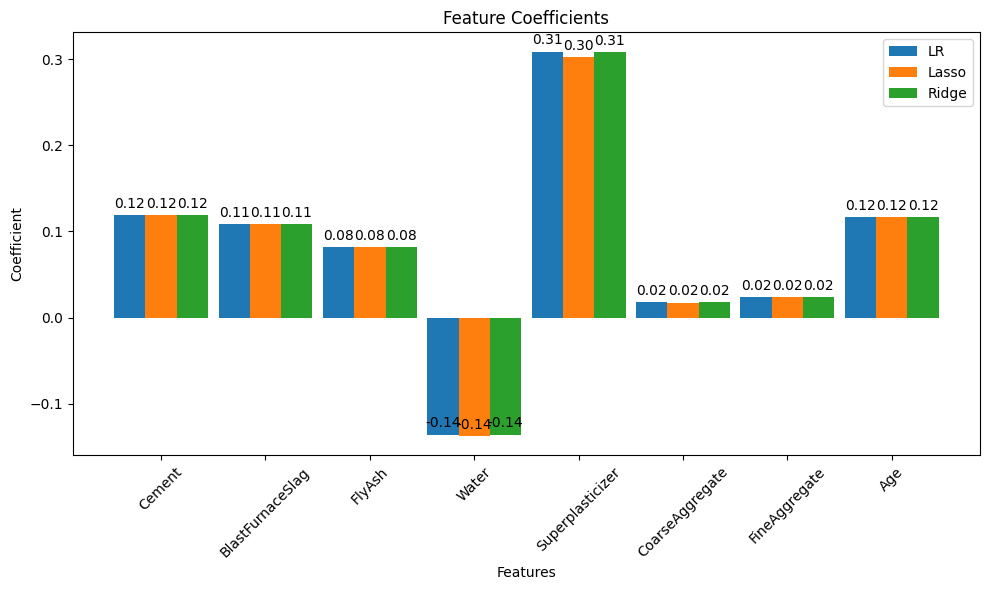

In [7]:
coeff_lr = lr.coef_
coeff_lasso = lasso.coef_
coeff_ridge = ridge.coef_

labels = req_col_names[:-1]
x = np.arange(len(labels)) 
width = 0.3

fig, ax = plt.subplots(figsize=(10,6))
rects1 = ax.bar(x - 2*(width/2), coeff_lr,    width, label='LR')
rects2 = ax.bar(x              , coeff_lasso, width, label='Lasso')
rects3 = ax.bar(x + 2*(width/2), coeff_ridge, width, label='Ridge')

ax.set_ylabel('Coefficient')
ax.set_xlabel('Features')
ax.set_title('Feature Coefficients')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45)
ax.legend()

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{:.2f}'.format(height), xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

fig.tight_layout()
plt.show()

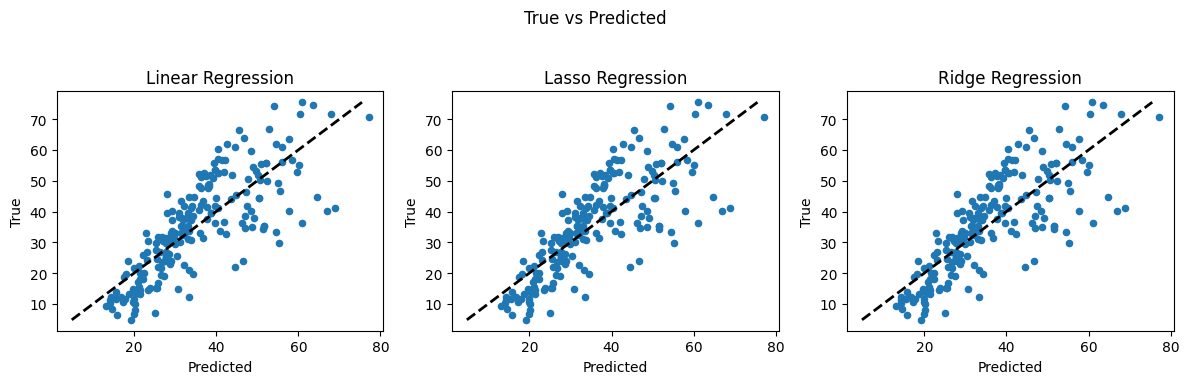

In [8]:
fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(12,4))

ax1.scatter(y_pred_lr, y_test, s=20)
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
ax1.set_ylabel("True")
ax1.set_xlabel("Predicted")
ax1.set_title("Linear Regression")

ax2.scatter(y_pred_lasso, y_test, s=20)
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
ax2.set_ylabel("True")
ax2.set_xlabel("Predicted")
ax2.set_title("Lasso Regression")

ax3.scatter(y_pred_ridge, y_test, s=20)
ax3.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
ax3.set_ylabel("True")
ax3.set_xlabel("Predicted")
ax3.set_title("Ridge Regression")

fig.suptitle("True vs Predicted")
fig.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [9]:
# Step 7: Weighted Least Squares Demo
import statsmodels.api as sm
from statsmodels.sandbox.regression.predstd import wls_prediction_std

nsample = 50
x = np.linspace(0, 20, nsample)
X = np.column_stack((x, (x - 5)**2))
X = sm.add_constant(X)
beta = [5., 0.5, -0.01]
sig = 0.5
w = np.ones(nsample)
w[int(nsample * 6/10):] = 3
y_true = np.dot(X, beta)
e = np.random.normal(size=nsample)
y = y_true + sig * w * e
X = X[:,[0,1]]

mod_wls = sm.WLS(y, X, weights=1./w)
res_wls = mod_wls.fit()
print(res_wls.summary())

                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.827
Model:                            WLS   Adj. R-squared:                  0.823
Method:                 Least Squares   F-statistic:                     229.6
Date:                Tue, 24 Jun 2025   Prob (F-statistic):           6.43e-20
Time:                        15:13:31   Log-Likelihood:                -73.915
No. Observations:                  50   AIC:                             151.8
Df Residuals:                      48   BIC:                             155.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.1520      0.259     19.866      0.0